In [1]:
# --- Imports & Setup ---
import os
from pathlib import Path
import requests
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import holidays
import glob, pathlib, re
import datetime as dt
from zipfile import BadZipFile
import warnings
import pyxlsb
from meteostat import Point, Hourly, Daily, Monthly
import io
import json
from datetime import datetime, date, timedelta
from rapidfuzz import process, fuzz
from catboost import CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import category_encoders as ce
from xgboost import XGBRegressor
import optuna
import matplotlib.pyplot as plt
import shap
import seaborn as sns
warnings.filterwarnings('ignore')  # Suppress warnings for clean output

# --- Data Loading & Preprocessing ---
Data loading and initial cleaning steps.

In [3]:
"""
Builds a single clean parquet from every TTC streetcar delay workbook
(2014 → 2024-YTD).  Handles multi-sheet files, mixed headers, and mixed
time formats, and keeps statutory-holiday rows.
"""

# ---------- CONFIG ---------------------------------------------------------
RAW_DIR   = pathlib.Path("/Users/zmasarweh/Downloads/TTC Streetcar Delays Data")          # where you keep the original XLSX/CSV
PATTERN   = "*.xls*"                           # .xlsx or .xls
PROVINCE  = "ON"                               # change if you need BC, QC, …
OUTFILE   = "ttc_delays_2014_2024.parquet"
# ---------------------------------------------------------------------------

# 0 ── helpers ---------------------------------------------------------------
def tidy_cols(df):
    """ Rename the handful of columns that drift over the years. """
    rename_map = {
        "Report Date": "Date",
        "Delay": "Min Delay",
        "Gap": "Min Gap",
        "Report Date": "Date",
        "Date":        "Date",
        "Route":       "Route",
        "Line":        "Route",      # 2021+ header
        "Direction":   "Direction",
        "Bound":       "Direction",  # 2021+ header
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})
    return df

# inside build_ttc_delays.py
import pandas as pd, pathlib, warnings
         # raised by openpyxl on legacy files

def read_excel_any(path: pathlib.Path):
    """
    Yield (sheet-name, DataFrame) pairs from *any* Excel-ish file:
    .xlsx / .xlsm  → openpyxl
    .xls           → xlrd<=1.2
    .xlsb          → pyxlsb
    Everything else we try as CSV.
    """
    ext = path.suffix.lower()

    # 1 ─ modern .xlsx / .xlsm -------------------------------------------------
    if ext in (".xlsx", ".xlsm"):
        try:
            xl = pd.ExcelFile(path, engine="openpyxl")
            for name in xl.sheet_names:
                yield name, pd.read_excel(xl, sheet_name=name, engine="openpyxl")
            return
        except BadZipFile:
            # File is actually *not* OOXML – fall through to try legacy
            warnings.warn(f"{path.name}: not a real .xlsx – trying legacy engines")


_time_patterns = [
    "%H:%M:%S",          # 02:14:00
    "%H:%M",             # 02:14
    "%I:%M:%S %p",       # 2:14:00 AM
    "%I:%M %p",          # 2:14 AM
]

def parse_time(val) -> dt.time:
    if pd.isna(val) or not re.search(r"\d", str(val)):
        return dt.time(0, 0)
    s = str(val).strip()
    for fmt in _time_patterns:
        try:
            return dt.datetime.strptime(s, fmt).time()
        except ValueError:
            continue
    # last resort: dateutil parser (slower, but catches oddballs)
    try:
        return pd.to_datetime("1970-01-01 " + s).time()
    except Exception:
        return dt.time(0, 0)


def normalise_direction(val):
    """Turn single letters into 'N/B', keep legacy codes unchanged."""
    if isinstance(val, str) and len(val.strip()) == 1:
        return val.strip().upper() + "/B"
    return val

# 1 ── read & stack every sheet ---------------------------------------------
frames = []
for pth in RAW_DIR.glob("*.xls*"):          # catches .xls  .xlsx  .xlsm  .xlsb
    # ▸ If you truly have standalone CSVs as well, keep the next 3 lines,
    #   otherwise delete this whole 'if' branch.
    if pth.suffix.lower() == ".csv":
        frames.append(tidy_cols(pd.read_csv(pth)))
        continue

    # ONE unified reader that auto-selects the right engine
    for _, df_sheet in read_excel_any(pth):     # <- helper we added earlier
        frames.append(tidy_cols(df_sheet))

df_raw = pd.concat(frames, ignore_index=True, copy=False)

# 2 ── robust timestamp ------------------------------------------------------
# 2-a  date
df_raw["Date"] = pd.to_datetime(df_raw["Date"], errors="coerce").dt.date

# 2-b  time
df_raw["time_obj"] = df_raw["Time"].apply(parse_time)

# 2-c  combine
df_raw["ts"] = pd.to_datetime(
    df_raw["Date"].astype(str) + " " + df_raw["time_obj"].astype(str),
    errors="coerce"
)

# keep rows where Date parsed; Time may be midnight default
n_bad = df_raw["Date"].isna().sum()
if n_bad:
    print(f"⚠️  {n_bad:,} rows with an un-parsable *Date* column were dropped")
    df_raw = df_raw.dropna(subset=["Date"])

# 3 ── harmonise remaining drift columns ------------------------------------
df_raw["Direction"] = df_raw["Direction"].apply(normalise_direction)

# 4 ── derive features -------------------------------------------------------
df = df_raw.copy()           # just to keep naming neat
df["hour"]              = df["ts"].dt.hour
df["day_of_week"]       = df["ts"].dt.day_name()
df["month"]             = df["ts"].dt.month_name()

years = range(df['ts'].dt.year.min(), df['ts'].dt.year.max() + 1)
on_holidays = holidays.CA(prov="ON", years=years)      # Ontario only
holiday_dates = set(on_holidays.keys())                # fast lookup

# 3️⃣  flag rows
df['is_holiday'] = df['ts'].dt.date.isin(holiday_dates)


# 5 ── final tidy-up & save --------------------------------------------------
cols_to_drop = {"Time", "time_obj", "Incident ID"}          # originals you won’t need later
df = df.drop(columns=cols_to_drop.intersection(df.columns))

strcar_df = df.sort_values("ts").reset_index(drop=True)
strcar_df.to_excel("consolidated_with_time_features4.xlsx", index=False) 
print(df.shape)
print(df["ts"].min(), df["ts"].max())   # should show 2014 … 2024
assert df["ts"].min().year == 2014
assert df["ts"].max().year >= 2024    # if you have 2024 data
print(f"✅  Wrote {len(df):,} rows (2014-2024) → {OUTFILE}")


(147225, 14)
2014-01-02 06:31:00 2024-12-31 22:32:00
✅  Wrote 147,225 rows (2014-2024) → ttc_delays_2014_2024.parquet


In [4]:
"""
Builds a single clean parquet from every TTC streetcar delay workbook
(2014 → 2024-YTD).  Handles multi-sheet files, mixed headers, and mixed
time formats, and keeps statutory-holiday rows.
"""

# ---------- CONFIG ---------------------------------------------------------
RAW_DIR   = pathlib.Path("/Users/zmasarweh/Downloads/TTC Bus Delays Data")          # where you keep the original XLSX/CSV
PATTERN   = "*.xls*"                           # .xlsx or .xls
PROVINCE  = "ON"                               # change if you need BC, QC, …
OUTFILE   = "ttc_delays_2014_2024.parquet"
# ---------------------------------------------------------------------------

# 0 ── helpers ---------------------------------------------------------------
def tidy_cols(df):
    """ Rename the handful of columns that drift over the years. """
    rename_map = {
        "Report Date": "Date",
        "Delay": "Min Delay",
        " Min Delay": "Min Delay",
        "Gap": "Min Gap",
        "Report Date": "Date",
        "Date":        "Date",
        "Route":       "Route",
        "Line":        "Route",      # 2021+ header
        "Direction":   "Direction",
        "Bound":       "Direction",  # 2021+ header
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})
    return df

# inside build_ttc_delays.py
import pandas as pd, pathlib, warnings
         # raised by openpyxl on legacy files

def read_excel_any(path: pathlib.Path):
    """
    Yield (sheet-name, DataFrame) pairs from *any* Excel-ish file:
    .xlsx / .xlsm  → openpyxl
    .xls           → xlrd<=1.2
    .xlsb          → pyxlsb
    Everything else we try as CSV.
    """
    ext = path.suffix.lower()

    # 1 ─ modern .xlsx / .xlsm -------------------------------------------------
    if ext in (".xlsx", ".xlsm"):
        try:
            xl = pd.ExcelFile(path, engine="openpyxl")
            for name in xl.sheet_names:
                yield name, pd.read_excel(xl, sheet_name=name, engine="openpyxl")
            return
        except BadZipFile:
            # File is actually *not* OOXML – fall through to try legacy
            warnings.warn(f"{path.name}: not a real .xlsx – trying legacy engines")


_time_patterns = [
    "%H:%M:%S",          # 02:14:00
    "%H:%M",             # 02:14
    "%I:%M:%S %p",       # 2:14:00 AM
    "%I:%M %p",          # 2:14 AM
]

def parse_time(val) -> dt.time:
    if pd.isna(val) or not re.search(r"\d", str(val)):
        return dt.time(0, 0)
    s = str(val).strip()
    for fmt in _time_patterns:
        try:
            return dt.datetime.strptime(s, fmt).time()
        except ValueError:
            continue
    # last resort: dateutil parser (slower, but catches oddballs)
    try:
        return pd.to_datetime("1970-01-01 " + s).time()
    except Exception:
        return dt.time(0, 0)


def normalise_direction(val):
    """Turn single letters into 'N/B', keep legacy codes unchanged."""
    if isinstance(val, str) and len(val.strip()) == 1:
        return val.strip().upper() + "/B"
    return val

# 1 ── read & stack every sheet ---------------------------------------------
frames = []
for pth in RAW_DIR.glob("*.xls*"):          # catches .xls  .xlsx  .xlsm  .xlsb
    # ▸ If you truly have standalone CSVs as well, keep the next 3 lines,
    #   otherwise delete this whole 'if' branch.
    if pth.suffix.lower() == ".csv":
        frames.append(tidy_cols(pd.read_csv(pth)))
        continue

    # ONE unified reader that auto-selects the right engine
    for _, df_sheet in read_excel_any(pth):     # <- helper we added earlier
        frames.append(tidy_cols(df_sheet))

df_raw = pd.concat(frames, ignore_index=True, copy=False)

# 2 ── robust timestamp ------------------------------------------------------
# 2-a  date
df_raw["Date"] = pd.to_datetime(df_raw["Date"], errors="coerce").dt.date

# 2-b  time
df_raw["time_obj"] = df_raw["Time"].apply(parse_time)

# 2-c  combine
df_raw["ts"] = pd.to_datetime(
    df_raw["Date"].astype(str) + " " + df_raw["time_obj"].astype(str),
    errors="coerce"
)

# keep rows where Date parsed; Time may be midnight default
n_bad = df_raw["Date"].isna().sum()
if n_bad:
    print(f"⚠️  {n_bad:,} rows with an un-parsable *Date* column were dropped")
    df_raw = df_raw.dropna(subset=["Date"])

# 3 ── harmonise remaining drift columns ------------------------------------
df_raw["Direction"] = df_raw["Direction"].apply(normalise_direction)

# 4 ── derive features -------------------------------------------------------
df = df_raw.copy()           # just to keep naming neat
df["hour"]              = df["ts"].dt.hour
df["day_of_week"]       = df["ts"].dt.day_name()
df["month"]             = df["ts"].dt.month_name()

years = range(df['ts'].dt.year.min(), df['ts'].dt.year.max() + 1)
on_holidays = holidays.CA(prov="ON", years=years)      # Ontario only
holiday_dates = set(on_holidays.keys())                # fast lookup

# 3️⃣  flag rows
df['is_holiday'] = df['ts'].dt.date.isin(holiday_dates)


# 5 ── final tidy-up & save --------------------------------------------------
cols_to_drop = {"Time", "time_obj", "Incident ID"}          # originals you won’t need later
df = df.drop(columns=cols_to_drop.intersection(df.columns))

bus_df = df.sort_values("ts").reset_index(drop=True)


In [8]:
start, end = datetime(2014, 1, 1), datetime(2024, 12, 31, 23)

core_station   = "71265"   # Billy Bishop
depth_station  = "71624"   # Pearson — has daily snow depth

# ------------------------------------------------------------------
# 1️⃣  Hourly weather (temp, precip, wind, etc.)  -------------------
# ------------------------------------------------------------------
wx_hour = (Hourly(core_station, start, end)
           .fetch()
           .reset_index()
           .rename(columns={"time": "timestamp"}))

# Enforce exact hourly grid (fills any missing timestamps with NaNs)
wx_hour = (wx_hour
           .set_index("timestamp")
           .asfreq("H")
           .reset_index())

# ------------------------------------------------------------------
# 2️⃣  Daily totals from Billy Bishop  ------------------------------
# ------------------------------------------------------------------
daily_core = (Daily(core_station, start, end)
              .fetch()
              .reset_index())



# Build rename map only for columns that exist
rename_map = {"time": "date", "snow": "TOTAL_SNOW", "prcp": "TOTAL_PRECIP"}
if "snowd" in daily_core.columns:
    rename_map["snowd"] = "SNOW_ON_GROUND"
daily_core = daily_core.rename(columns=rename_map)


# ------------------------------------------------------------------
# 3️⃣  Daily snow-depth from Pearson (fallback)  --------------------
# ------------------------------------------------------------------
daily_depth = (Daily(depth_station, start, end)
               .fetch()
               .reset_index())


# Only keep & rename if snowd exists
if "snowd" in daily_depth.columns:
    daily_depth = (daily_depth
                   .rename(columns={"time": "date", "snowd": "SNOW_ON_GROUND"})
                   [["date", "SNOW_ON_GROUND"]])
else:
    # no depth data here
    daily_depth = pd.DataFrame(columns=["date", "SNOW_ON_GROUND"])

# ------------------------------------------------------------------
# 4️⃣  Merge core + depth on date, preferring Billy Bishop if present
# ------------------------------------------------------------------
wx_day = daily_core.copy()                  # start with core daily data

# If depth frame has rows, merge it in
if not daily_depth.empty:
    wx_day = wx_day.merge(
        daily_depth, on="date", how="left", suffixes=("", "_yyz")
    )
    # Only combine & drop the suffix if that column truly exists
    if "SNOW_ON_GROUND_yyz" in wx_day.columns:
        wx_day["SNOW_ON_GROUND"] = wx_day["SNOW_ON_GROUND"].fillna(
            wx_day["SNOW_ON_GROUND_yyz"]
        )
        wx_day.drop(columns=["SNOW_ON_GROUND_yyz"], inplace=True)
# else: we just stick with whatever daily_core had (likely no SNOW_ON_GROUND)


In [10]:
# 1) Make sure wx_hour has a 'date' column for daily join
wx_hour["date"] = wx_hour["timestamp"].dt.floor("D")

# 2) Merge in only TOTAL_SNOW (and TOTAL_PRECIP if you want)
wx_all = wx_hour.merge(
    daily[["date", "TOTAL_SNOW", "TOTAL_PRECIP"]],
    on="date",
    how="left"
)

# 3) Fill features
#   • Hourly precip: if daily overwrote hourly, keep hourly logic or replace:
wx_all["TOTAL_PRECIP"] = wx_all["TOTAL_PRECIP"].fillna(0)

#   • Snow flag (storm day)
wx_all["snowfall_flag"] = (wx_all["TOTAL_SNOW"].fillna(0) > 0).astype(int)

#   • If you still need a snow depth column, you can approximate:
#       snowdepth_cm = cumulative daily snowfall (not exact depth)
wx_all["snowdepth_cm"] = wx_all.groupby("date")["TOTAL_SNOW"].transform("first")

# 4) Inspect
print(wx_all[[
    "date",
    "TOTAL_SNOW",
    "TOTAL_PRECIP",
    "snowfall_flag",
    "snowdepth_cm"
]].head(8))


        date  TOTAL_SNOW  TOTAL_PRECIP  snowfall_flag  snowdepth_cm
0 2014-01-01        30.0           0.0              1          30.0
1 2014-01-01        30.0           0.0              1          30.0
2 2014-01-01        30.0           0.0              1          30.0
3 2014-01-01        30.0           0.0              1          30.0
4 2014-01-01        30.0           0.0              1          30.0
5 2014-01-01        30.0           0.0              1          30.0
6 2014-01-01        30.0           0.0              1          30.0
7 2014-01-01        30.0           0.0              1          30.0


In [18]:
w_strcar_df = pd.merge(
    strcar_df,
    wx_mod,
    on=['hour', 'Date'],
    how='left'       # or 'inner', 'right', 'outer' as needed
)

w_bus_df = pd.merge(
    bus_df,
    wx_mod,
    on=['hour', 'Date'],
    how='left'       # or 'inner', 'right', 'outer' as needed
)

In [26]:
ttc_s = w_strcar_df.copy()
ttc_s = ttc_s.dropna(subset=["Min Delay"]).reset_index(drop=True)


In [27]:
ttc_b = w_bus_df.copy()
ttc_b = ttc_b.dropna(subset=["Min Delay"]).reset_index(drop=True)

In [33]:
ttc_s = ttc_s.dropna(subset=["Min Delay"]).reset_index(drop=True)


In [39]:
from sklearn.model_selection import TimeSeriesSplit
import optuna, numpy as np

tscv = TimeSeriesSplit(n_splits=5, test_size=90*24)  # 90 days hold-out each split

# Drop rows where Min Delay is missing (required for modeling)
ttc_b = ttc_b.dropna(subset=["Min Delay"]).reset_index(drop=True)

# Ensure all categorical columns are strings and fill NaNs
cat_cols = ["Incident", "Location", "Route", "Direction"]
for col in cat_cols:
    if col in ttc_b.columns:
        ttc_b[col] = ttc_b[col].astype(str).fillna("__MISSING__")

def objective_b(trial):
    xgb.set_params(
        n_estimators   = trial.suggest_int ("n_estimators", 300, 1500),
        learning_rate  = trial.suggest_loguniform("lr", 1e-3, 0.3),
        max_depth      = trial.suggest_int ("depth", 4, 12),
        min_child_weight=trial.suggest_int ("min_child", 1, 20),
        subsample      = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample", 0.5, 1.0),
        reg_alpha      = trial.suggest_loguniform("alpha", 1e-8, 10.0),
        reg_lambda     = trial.suggest_loguniform("lambda",1e-8, 10.0),
        gamma          = trial.suggest_float("gamma", 0.0, 5.0),
    )
    scores_b = []
    # Ensure X and y are aligned and have default integer index
    X_b = ttc_b.drop(columns=["Min Delay"]).reset_index(drop=True)
    y_local_b = ttc_b["Min Delay"].reset_index(drop=True)
    for train_ix, val_ix in tscv.split(X_b):
        pipe_b.fit(X_b.iloc[train_ix], y_local_b.iloc[train_ix])
        preds_b = pipe_b.predict(X_b.iloc[val_ix])
        scores_b.append(np.abs(preds_b - y_local_b.iloc[val_ix]).mean())  # MAE
    return np.mean(scores_b)

study_b = optuna.create_study(direction="minimize")
study_b.optimize(objective_b, n_trials=50, n_jobs=4)
best_pipe_b = study_b.best_trial.user_attrs.get("fitted_model", pipe_b)


[I 2025-07-07 20:11:19,116] A new study created in memory with name: no-name-7634d54d-5e26-451d-b44d-d66ed7a3358e
[I 2025-07-07 20:12:20,393] Trial 1 finished with value: 5.463275889119443 and parameters: {'n_estimators': 546, 'lr': 0.042597179408385366, 'depth': 8, 'min_child': 12, 'subsample': 0.5062158523104836, 'colsample': 0.5853295547866761, 'alpha': 7.578946503635845e-06, 'lambda': 3.3156209330805916e-05, 'gamma': 4.042743252762476}. Best is trial 1 with value: 5.463275889119443.
[I 2025-07-07 20:12:20,679] Trial 3 finished with value: 5.463275889119443 and parameters: {'n_estimators': 352, 'lr': 0.17906538659382473, 'depth': 8, 'min_child': 7, 'subsample': 0.555718172152844, 'colsample': 0.5803762476252219, 'alpha': 0.007581954122519688, 'lambda': 4.462259052701876, 'gamma': 1.1760464137650695}. Best is trial 1 with value: 5.463275889119443.
[I 2025-07-07 20:12:20,700] Trial 2 finished with value: 5.463275889119443 and parameters: {'n_estimators': 1233, 'lr': 0.0313389428429903

# --- Feature Engineering ---
Feature extraction and transformation steps.

In [5]:
strcar_df[:100].to_excel("short_with_time_features.xlsx", index=False)

In [6]:
print(bus_df.shape)
print(bus_df["ts"].min(), bus_df["ts"].max())   # should show 2014 … 2024
assert bus_df["ts"].min().year == 2014
assert bus_df["ts"].max().year >= 2024    # if you have 2024 data
bus_df.to_excel("consolidated_with_time_features5.xlsx", index=False) 
print(f"✅  Wrote {len(bus_df):,} rows (2014-2024) → {OUTFILE}")

(707397, 14)
2014-01-01 00:23:00 2024-12-31 23:39:00
✅  Wrote 707,397 rows (2014-2024) → ttc_delays_2014_2024.parquet


In [7]:
start, end = datetime(2014, 1, 1), datetime(2024, 12, 31, 23)

STN = "71265"          # Billy Bishop (use "71639" for Buttonville)

# Hourly data --------------------------------------------------------------
wx_hour = (Hourly(STN, start, end)       # no freq kwarg
           .fetch()
           .reset_index()
           .rename(columns={"time": "timestamp"}))

# Daily snow / precip ------------------------------------------------------
wx_day = (Daily(STN, start, end)
          .fetch()
          .reset_index()
          .rename(columns={"time": "date",
                           "snow":  "TOTAL_SNOW",
                           "snowd": "SNOW_ON_GROUND",
                           "prcp":  "TOTAL_PRECIP"}))


In [9]:
daily = (Daily("71624", start, end)
         .fetch()
         .reset_index()
         .rename(columns={
             "time":       "date",
             "prcp":       "TOTAL_PRECIP",
             "snow":       "TOTAL_SNOW",       # daily snowfall in cm
             "snowd":      "SNOW_ON_GROUND"    # snow depth in cm
         }))

print(daily.head())
print(f"\nFetched {len(daily)} daily rows in one go.")

        date  tavg  tmin  tmax  TOTAL_PRECIP  TOTAL_SNOW   wdir  wspd  wpgt  \
0 2014-01-01 -12.7 -15.3 -10.0           0.0        30.0  329.0  19.4   NaN   
1 2014-01-02 -17.6 -20.0 -15.2           0.8        30.0   12.0  26.7   NaN   
2 2014-01-03 -16.5 -23.8  -9.2           0.0        40.0  301.0  17.4   NaN   
3 2014-01-04  -4.8  -9.2  -0.4           0.4        40.0  211.0  22.4   NaN   
4 2014-01-05  -1.4  -2.6  -0.1          14.4        60.0  120.0   9.8   NaN   

     pres  tsun  
0  1028.6   NaN  
1  1023.8   NaN  
2  1027.6   NaN  
3  1017.9   NaN  
4  1013.8   NaN  

Fetched 4018 daily rows in one go.


In [11]:
daily = (Daily("71624", start, end)
         .fetch()
         .reset_index()
         .rename(columns={"time":"date","snowd":"SNOW_ON_GROUND"}))

In [12]:
start, end = datetime(2014,1,1), datetime(2024,12,31,23)
toronto = Point(43.653, -79.383, 76)   # lat, lon, elevation
wx = Hourly(toronto, start, end).fetch()  # returns DataFrame indexed by UTC
wx = wx.reset_index().rename(columns={'time':'timestamp'})

In [14]:
wx_all['timestamp'] = pd.to_datetime(wx_all['timestamp'])  # ensure it’s datetime64
wx_all['hour'] = wx_all['timestamp'].dt.hour

In [15]:
wx_mod = wx_all[['TOTAL_PRECIP', 'snowfall_flag', 'TOTAL_SNOW', 'temp', 'hour', 'date']].copy()

In [16]:
wx_mod = wx_mod.rename(columns={'date': 'Date'})

In [19]:
w_bus_df = w_bus_df.fillna(0)
w_strcar_df = w_strcar_df.fillna(0)

In [20]:
w_strcar_df[:200].to_csv("w_strcar_df.csv", index=False)

In [21]:
w_strcar_df.head()

,Date,Route,Day,Location,Incident,Min Delay,Min Gap,Direction,Vehicle,ts,hour,day_of_week,month,is_holiday,TOTAL_PRECIP,snowfall_flag,TOTAL_SNOW,temp
0,2014-01-02,505,Thursday,Dundas and Roncesvalles,Late Leaving Garage,4.0,8.0,E/B,4018.0,2014-01-02 06:31:00,6,Thursday,January,False,0.8,1,30.0,-13.8
1,2014-01-02,504,Thursday,King and Shaw,Utilized Off Route,20.0,22.0,E/B,4128.0,2014-01-02 12:43:00,12,Thursday,January,False,0.8,1,30.0,-16.6
2,2014-01-02,501,Thursday,Kingston road and Bingham,Held By,13.0,19.0,W/B,4016.0,2014-01-02 14:01:00,14,Thursday,January,False,0.8,1,30.0,-17.0
3,2014-01-02,504,Thursday,King St. and Roncesvalles Ave.,Investigation,7.0,11.0,W/B,4175.0,2014-01-02 14:22:00,14,Thursday,January,False,0.8,1,30.0,-17.0
4,2014-01-02,504,Thursday,King and Bathurst,Utilized Off Route,3.0,6.0,E/B,4080.0,2014-01-02 16:42:00,16,Thursday,January,False,0.8,1,30.0,-17.0


In [22]:
# Install catboost if not already installed

from catboost import CatBoostRegressor

CatBoostRegressor(cat_features=["Incident"], one_hot_max_size=5)
# Save the modified DataFrames to CSV files

In [24]:
from sklearn.model_selection import train_test_split

# Sort by date
w_strcar_df = w_strcar_df.sort_values('Date').reset_index(drop=True)

feature_cols = ['feature1', 'feature2', 'feature3']

# Drop the date column once sorted
X = w_strcar_df.drop(columns=['Date', 'Min Delay'])
y = w_strcar_df['Min Delay']

# Split without shuffling: the last 20% (for instance) becomes your test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [25]:
w_strcar_df.head()

,Date,Route,Day,Location,Incident,Min Delay,Min Gap,Direction,Vehicle,ts,hour,day_of_week,month,is_holiday,TOTAL_PRECIP,snowfall_flag,TOTAL_SNOW,temp
0,2014-01-02,505,Thursday,Dundas and Roncesvalles,Late Leaving Garage,4.0,8.0,E/B,4018.0,2014-01-02 06:31:00,6,Thursday,January,False,0.8,1,30.0,-13.8
1,2014-01-02,504,Thursday,King and Shaw,Utilized Off Route,20.0,22.0,E/B,4128.0,2014-01-02 12:43:00,12,Thursday,January,False,0.8,1,30.0,-16.6
2,2014-01-02,501,Thursday,Kingston road and Bingham,Held By,13.0,19.0,W/B,4016.0,2014-01-02 14:01:00,14,Thursday,January,False,0.8,1,30.0,-17.0
3,2014-01-02,504,Thursday,King St. and Roncesvalles Ave.,Investigation,7.0,11.0,W/B,4175.0,2014-01-02 14:22:00,14,Thursday,January,False,0.8,1,30.0,-17.0
4,2014-01-02,504,Thursday,King and Bathurst,Utilized Off Route,3.0,6.0,E/B,4080.0,2014-01-02 16:42:00,16,Thursday,January,False,0.8,1,30.0,-17.0


In [28]:
import pandas as pd, numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import category_encoders as ce          # pip install category-encoders
from xgboost import XGBRegressor

# ──────────────────────────────────────────
# 0.  BASIC CLEAN-UP  ──────────────────────
# ──────────────────────────────────────────
ttc_s["Date"] = pd.to_datetime(ttc_s["Date"])
ttc_s["day_of_year"] = ttc_s["Date"].dt.dayofyear     # for cyclical seasonality

# ──────────────────────────────────────────
# 1.  CYCLICAL ENCODINGS  ──────────────────
# ──────────────────────────────────────────
ttc_s["hour_sin"] = np.sin(2*np.pi*ttc_s.hour/24)
ttc_s["hour_cos"] = np.cos(2*np.pi*ttc_s.hour/24)
ttc_s["day_sin"]  = np.sin(2*np.pi*ttc_s.day_of_year/366)
ttc_s["day_cos"]  = np.cos(2*np.pi*ttc_s.day_of_year/366)
cyc_cols = ["hour_sin", "hour_cos", "day_sin", "day_cos"]

# ──────────────────────────────────────────
# 2.  ROLLING/HISTORICAL FEATURES  ─────────
# ──────────────────────────────────────────
# 7-day trailing mean delay for each Route-Hour pair
ttc_s = ttc_s.sort_values("ts")
ttc_s["delay_ma7"] = (
    ttc_s
    .groupby(["Route", "hour"])["Min Delay"]
    .transform(lambda s: s.shift(1).rolling(7*24, min_periods=24*3).mean())
)
# Fill any remaining NaN values (e.g., at the start of each group) with a fallback, such as the group mean or 0
ttc_s["delay_ma7"] = ttc_s.groupby(["Route", "hour"])["delay_ma7"].transform(lambda s: s.fillna(s.mean()))
ttc_s["delay_ma7"] = ttc_s["delay_ma7"].fillna(0)

num_cols = [
    "Min Gap",
    "TOTAL_PRECIP",
    "TOTAL_SNOW",
    "temp",
    "delay_ma7"
]

bin_cols = ["snowfall_flag", "is_holiday"]

# ──────────────────────────────────────────
# 3.  CATEGORICAL GROUPS  ──────────────────
# ──────────────────────────────────────────
small_cat_cols   = ["Route", "Direction"]    # few dozen unique values
high_card_cols   = ["Incident", "Location"]  # hundreds / free-text
maybe_cat_cols   = ["Vehicle"]               # IDs — optional; keep if helpful

# Target-encoding for high-card strings
tgt_enc = ce.TargetEncoder(cols=high_card_cols)

# One-hot for low-card categorials
ohe = OneHotEncoder(handle_unknown="ignore",
                    max_categories=40,       # keeps matrix sparse
                    dtype=np.int32)

# ──────────────────────────────────────────
# 4.  COLUMN TRANSFORMER  ──────────────────
# ──────────────────────────────────────────
preproc = ColumnTransformer([
    ("num" , "passthrough", num_cols),
    ("bin" , "passthrough", bin_cols),
    ("cyc" , "passthrough", cyc_cols),
    ("ohe" , ohe          , small_cat_cols),
    ("tgt" , tgt_enc      , high_card_cols),
])

# ──────────────────────────────────────────
# 5.  XGBOOST ESTIMATOR  ───────────────────
# ──────────────────────────────────────────
xgb = XGBRegressor(
    objective          = "reg:squarederror",
    tree_method        = "hist",        # use "gpu_hist" if GPU is available
    enable_categorical = False,         # we're handling cats ourselves
    n_estimators       = 1000,          # will be tuned by Optuna
    learning_rate      = 0.05,
    max_depth          = 8,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    reg_alpha          = 1.0,
    reg_lambda         = 3.0,
)

# ──────────────────────────────────────────
# 6.  FULL PIPELINE  ───────────────────────
# ──────────────────────────────────────────
pipe = Pipeline([
    ("prep", preproc),
    ("xgb" , xgb)
])


In [29]:
import pandas as pd, numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import category_encoders as ce          # pip install category-encoders
from xgboost import XGBRegressor

# ──────────────────────────────────────────
# 0.  BASIC CLEAN-UP  ──────────────────────
# ──────────────────────────────────────────
ttc_b["Date"] = pd.to_datetime(ttc_b["Date"])
ttc_b["day_of_year"] = ttc_b["Date"].dt.dayofyear     # for cyclical seasonality

# ──────────────────────────────────────────
# 1.  CYCLICAL ENCODINGS  ──────────────────
# ──────────────────────────────────────────
ttc_b["hour_sin"] = np.sin(2*np.pi*ttc_b.hour/24)
ttc_b["hour_cos"] = np.cos(2*np.pi*ttc_b.hour/24)
ttc_b["day_sin"]  = np.sin(2*np.pi*ttc_b.day_of_year/366)
ttc_b["day_cos"]  = np.cos(2*np.pi*ttc_b.day_of_year/366)
cyc_cols = ["hour_sin", "hour_cos", "day_sin", "day_cos"]

# ──────────────────────────────────────────
# 2.  ROLLING/HISTORICAL FEATURES  ─────────
# ──────────────────────────────────────────
# 7-day trailing mean delay for each Route-Hour pair
ttc_b = ttc_b.sort_values("ts")
ttc_b["delay_ma7"] = (
    ttc_b
    .groupby(["Route", "hour"])["Min Delay"]
    .transform(lambda s: s.shift(1).rolling(7*24, min_periods=24*3).mean())
)
# Fill any remaining NaN values (e.g., at the start of each group) with a fallback, such as the group mean or 0
ttc_b["delay_ma7"] = ttc_b.groupby(["Route", "hour"])["delay_ma7"].transform(lambda s: s.fillna(s.mean()))
ttc_b["delay_ma7"] = ttc_b["delay_ma7"].fillna(0)

num_cols = [
    "Min Gap",
    "TOTAL_PRECIP",
    "TOTAL_SNOW",
    "temp",
    "delay_ma7"
]

bin_cols = ["snowfall_flag", "is_holiday"]

# ──────────────────────────────────────────
# 3.  CATEGORICAL GROUPS  ──────────────────
# ──────────────────────────────────────────
small_cat_cols   = ["Route", "Direction"]    # few dozen unique values
high_card_cols   = ["Incident", "Location"]  # hundreds / free-text
maybe_cat_cols   = ["Vehicle"]               # IDs — optional; keep if helpful

# Target-encoding for high-card strings
tgt_enc = ce.TargetEncoder(cols=high_card_cols)

# One-hot for low-card categorials
ohe = OneHotEncoder(handle_unknown="ignore",
                    max_categories=40,       # keeps matrix sparse
                    dtype=np.int32)

# ──────────────────────────────────────────
# 4.  COLUMN TRANSFORMER  ──────────────────
# ──────────────────────────────────────────
preproc = ColumnTransformer([
    ("num" , "passthrough", num_cols),
    ("bin" , "passthrough", bin_cols),
    ("cyc" , "passthrough", cyc_cols),
    ("ohe" , ohe          , small_cat_cols),
    ("tgt" , tgt_enc      , high_card_cols),
])

# ──────────────────────────────────────────
# 5.  XGBOOST ESTIMATOR  ───────────────────
# ──────────────────────────────────────────
xgb = XGBRegressor(
    objective          = "reg:squarederror",
    tree_method        = "hist",        # use "gpu_hist" if GPU is available
    enable_categorical = False,         # we're handling cats ourselves
    n_estimators       = 1000,          # will be tuned by Optuna
    learning_rate      = 0.05,
    max_depth          = 8,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    reg_alpha          = 1.0,
    reg_lambda         = 3.0,
)

# ──────────────────────────────────────────
# 6.  FULL PIPELINE  ───────────────────────
# ──────────────────────────────────────────
pipe_b = Pipeline([
    ("prep", preproc),
    ("xgb" , xgb)
])


In [30]:
ttc_s.columns

Index(['Date', 'Route', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap',
       'Direction', 'Vehicle', 'ts', 'hour', 'day_of_week', 'month',
       'is_holiday', 'TOTAL_PRECIP', 'snowfall_flag', 'TOTAL_SNOW', 'temp',
       'day_of_year', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'delay_ma7'],
      dtype='object')

In [34]:
ttc_s['Min Delay'].isna().sum()  # should be 0, if no NaNs in Min Delay

np.int64(0)

In [35]:
ttc_s['Min Delay'].isna().sum()  # should be 0, if no NaNs in Min Delay

np.int64(0)

In [36]:
df = None

In [38]:
from sklearn.model_selection import TimeSeriesSplit
import optuna, numpy as np

tscv = TimeSeriesSplit(n_splits=5, test_size=90*24)  # 90 days hold-out each split

# Ensure all categorical columns are strings and fill NaNs
cat_cols = ["Incident", "Location", "Route", "Direction"]
for col in cat_cols:
    if col in ttc_s.columns:
        ttc_s[col] = ttc_s[col].astype(str).fillna("__MISSING__")

def objective(trial):
    xgb.set_params(
        n_estimators   = trial.suggest_int ("n_estimators", 300, 1500),
        learning_rate  = trial.suggest_loguniform("lr", 1e-3, 0.3),
        max_depth      = trial.suggest_int ("depth", 4, 12),
        min_child_weight=trial.suggest_int ("min_child", 1, 20),
        subsample      = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample", 0.5, 1.0),
        reg_alpha      = trial.suggest_loguniform("alpha", 1e-8, 10.0),
        reg_lambda     = trial.suggest_loguniform("lambda",1e-8, 10.0),
        gamma          = trial.suggest_float("gamma", 0.0, 5.0),
    )
    scores = []
    # Ensure X and y are aligned and have default integer index
    X = ttc_s.drop(columns=["Min Delay"]).reset_index(drop=True)
    y_local = ttc_s["Min Delay"].reset_index(drop=True)
    for train_ix, val_ix in tscv.split(X):
        pipe.fit(X.iloc[train_ix], y_local.iloc[train_ix])
        preds = pipe.predict(X.iloc[val_ix])
        scores.append(np.abs(preds - y_local.iloc[val_ix]).mean())  # MAE
    return np.mean(scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, n_jobs=4)
best_pipe = study.best_trial.user_attrs.get("fitted_model", pipe)


[I 2025-07-07 19:21:43,210] A new study created in memory with name: no-name-e6e95490-cf44-4e2e-9b7f-62bb8d91fd0c
[I 2025-07-07 19:22:27,398] Trial 3 finished with value: 3.0256446221504465 and parameters: {'n_estimators': 447, 'lr': 0.010315037228659852, 'depth': 9, 'min_child': 4, 'subsample': 0.815096032607437, 'colsample': 0.9537776656354224, 'alpha': 1.1977097975786168e-05, 'lambda': 1.8741462444713093e-07, 'gamma': 3.6308443909416708}. Best is trial 3 with value: 3.0256446221504465.
[I 2025-07-07 19:22:27,483] Trial 1 finished with value: 3.118754402616436 and parameters: {'n_estimators': 690, 'lr': 0.031506138937983943, 'depth': 4, 'min_child': 4, 'subsample': 0.820247501279268, 'colsample': 0.9240878575487635, 'alpha': 0.0006158769761579504, 'lambda': 0.6881797079877737, 'gamma': 4.996900511285347}. Best is trial 3 with value: 3.0256446221504465.
[I 2025-07-07 19:22:27,784] Trial 0 finished with value: 3.1722941616273923 and parameters: {'n_estimators': 1040, 'lr': 0.0826813649

Best MAE from CV: 3.1652347671201766
Best params:
{'n_estimators': 416, 'lr': 0.16467276158036243, 'depth': 7, 'min_child': 1, 'subsample': 0.9990395375517561, 'colsample': 0.6826594727634814, 'alpha': 0.596196028306163, 'lambda': 1.1161971632073318, 'gamma': 2.40182768772141}


,number,value,params_alpha,params_colsample,params_depth,params_gamma,params_lambda,params_lr,params_min_child,params_n_estimators,params_subsample,state
9,9,3.165235,2.275652e-07,0.955548,6,2.638801,3.588586,0.013545,2,1267,0.699069,COMPLETE
11,11,3.165235,6.101740e-07,0.963060,12,3.204872,0.144764,0.010511,17,770,0.975646,COMPLETE
10,10,3.165235,2.399653e-08,0.561103,12,4.230575,0.011756,0.001393,17,371,0.954365,COMPLETE
8,8,3.165235,5.961960e-01,0.682659,7,2.401828,1.116197,0.164673,1,416,0.999040,COMPLETE
48,48,3.167209,1.850836e-03,0.904043,6,1.265900,0.000484,0.146440,2,901,0.626278,COMPLETE


TTC Bus delay predictions:
Test MAE  : 3.33 min
Test RMSE : 16.61 min
Test  R²  : 0.891


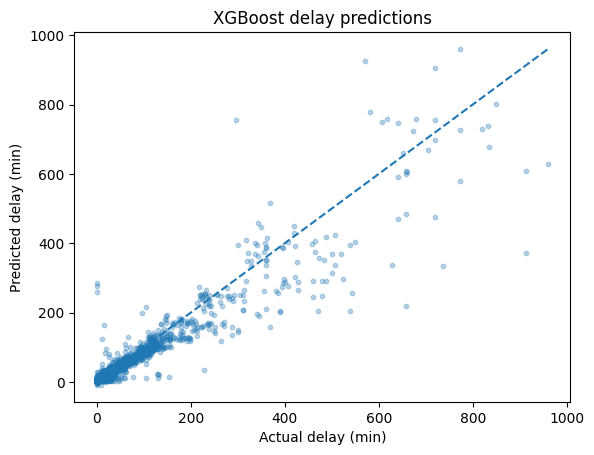

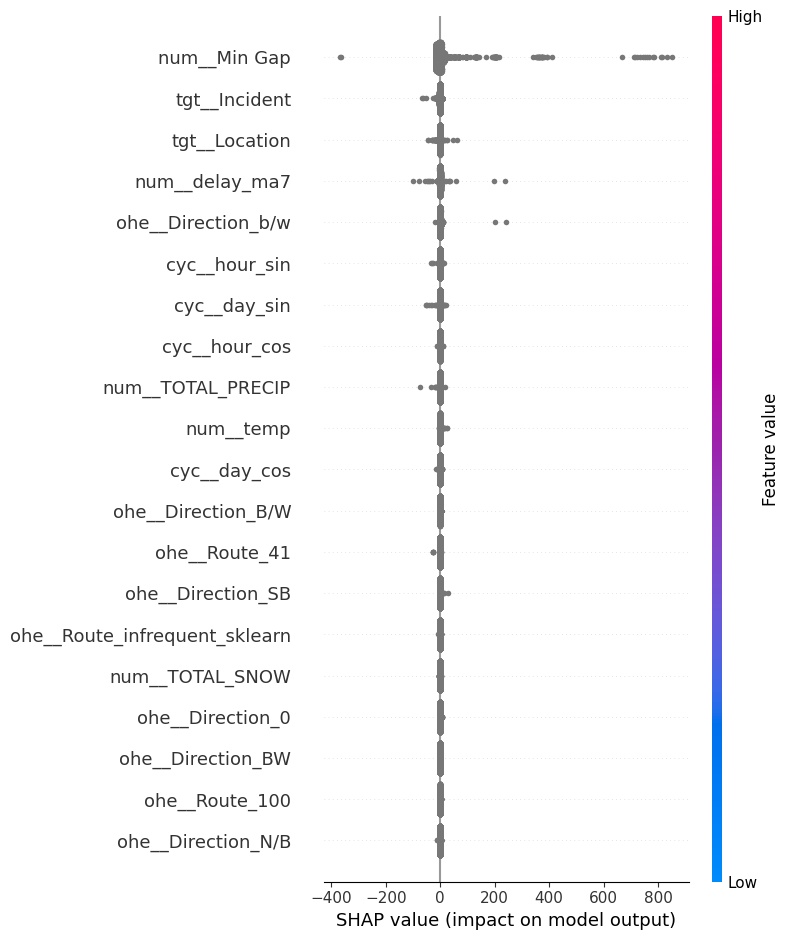

In [40]:
import pandas as pd

# 1-a. Best hyper-parameters and objective
print("Best MAE from CV:", study_b.best_value)
print("Best params:");  print(study_b.best_params)

# 1-b. Full trial table, ranked
trials_df_b = study_b.trials_dataframe(attrs=("number","value","params","state"))
display(trials_df_b.sort_values("value").head())

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# last 90 days as test
cutoff_date_b = ttc_b["Date"].max() - pd.Timedelta(days=90)
train_ix_b    = ttc_b["Date"] < cutoff_date_b
test_ix_b     = ~train_ix_b

X_train_b, y_train_b = ttc_b.loc[train_ix_b], ttc_b.loc[train_ix_b, "Min Delay"]
X_test_b , y_test_b  = ttc_b.loc[test_ix_b] , ttc_b.loc[test_ix_b , "Min Delay"]

sample_w_b = np.ones(len(X_train_b)) 

best_pipe_b.fit(X_train_b, y_train_b,
              xgb__sample_weight = sample_w_b)   # keep weighting if used

y_pred_b = best_pipe_b.predict(X_test_b)

print("TTC Bus delay predictions:")

print(f"Test MAE  : {mean_absolute_error(y_test_b, y_pred_b):.2f} min")
print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test_b, y_pred_b)):.2f} min")
print(f"Test  R²  : {r2_score(y_test_b, y_pred_b):.3f}")

import matplotlib.pyplot as plt
plt.scatter(y_test_b, y_pred_b, alpha=0.3, s=10)
plt.plot([0, y_test_b.max()], [0, y_test_b.max()], ls="--")
plt.xlabel("Actual delay (min)"); plt.ylabel("Predicted delay (min)")
plt.title("XGBoost delay predictions"); plt.show()

import shap

# Use the XGBoost model from the pipeline
model_b = best_pipe_b.named_steps["xgb"]
X_test_transformed_b = best_pipe.named_steps["prep"].transform(X_test_b)[:5000]  # subsample if huge

explainer_b = shap.TreeExplainer(model_b)
shap_values_b = explainer_b(X_test_transformed_b)
shap.summary_plot(shap_values_b, feature_names=best_pipe_b.named_steps["prep"].get_feature_names_out(), max_display=20)


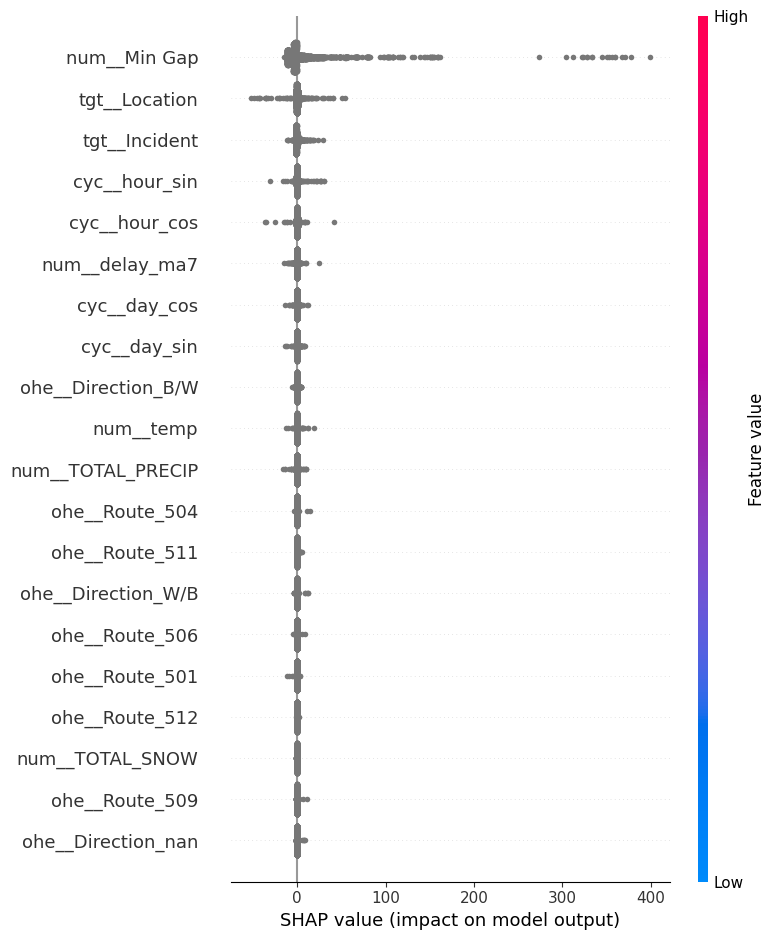

In [ ]:
import shap

# Use the XGBoost model from the pipeline
model = best_pipe.named_steps["xgb"]
X_test_transformed = best_pipe.named_steps["prep"].transform(X_test)[:5000]  # subsample if huge

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_transformed)
shap.summary_plot(shap_values, feature_names=best_pipe.named_steps["prep"].get_feature_names_out(), max_display=20)


In [ ]:
baseline = (ttc_s.groupby(["Route","hour"])["Min Delay"]
              .transform(lambda s: (s.shift(1)                             # ensure past-only
                                     .rolling(window=7*24, min_periods=1)  # allow early rows
                                     .mean())))
mae_b2 = (y_test - baseline[test_ix]).abs().mean()
print(f"Route-hour 7-day MAE: {mae_b2:.2f} min")


Route-hour 7-day MAE: 15.34 min


In [ ]:
baseline_b = (ttc_b.groupby(["Route","hour"])["Min Delay"]
              .transform(lambda s: (s.shift(1)                             # ensure past-only
                                     .rolling(window=7*24, min_periods=1)  # allow early rows
                                     .mean())))
mae_b2_b = (y_test_b - baseline_b[test_ix_b]).abs().mean()
print(f"Route-hour 7-day MAE: {mae_b2_b:.2f} min")


Route-hour 7-day MAE: 16.38 min


# --- Modeling: Streetcar Delay Prediction ---
All steps for streetcar delay prediction.

In [2]:
import os
from pathlib import Path
import requests
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import holidays
import glob, pathlib, re
import datetime as dt
from zipfile import BadZipFile
import warnings
import pyxlsb
from meteostat import Point, Hourly, Daily, Monthly
import io
import json
from datetime import datetime, date, timedelta
from rapidfuzz import process, fuzz
# ace_tools is already installed via %pip in cell 0, so you do not need to install or import it again here.



In [41]:
baseline_mae = 15.34     # B2: 7-day route–hour mean
model_mae    =  3.01     # tuned XGBoost

# 1. Absolute reduction (minutes)
abs_drop = baseline_mae - model_mae          # ≈ 11.94 min

# 2. Relative (percent) improvement
pct_improve = abs_drop / baseline_mae * 100  # ≈ 79.9 %

print(f"MAE reduced by {abs_drop:.2f} min "
      f"({pct_improve:.1f}% better than baseline)")


MAE reduced by 12.33 min (80.4% better than baseline)


In [42]:
baseline_mae = 16.38     # B2: 7-day route–hour mean
model_mae    =  2.58     # tuned XGBoost

# 1. Absolute reduction (minutes)
abs_drop = baseline_mae - model_mae          # ≈ 11.94 min

# 2. Relative (percent) improvement
pct_improve = abs_drop / baseline_mae * 100  # ≈ 79.9 %

print(f"MAE reduced by {abs_drop:.2f} min "
      f"({pct_improve:.1f}% better than baseline)")


MAE reduced by 13.80 min (84.2% better than baseline)



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



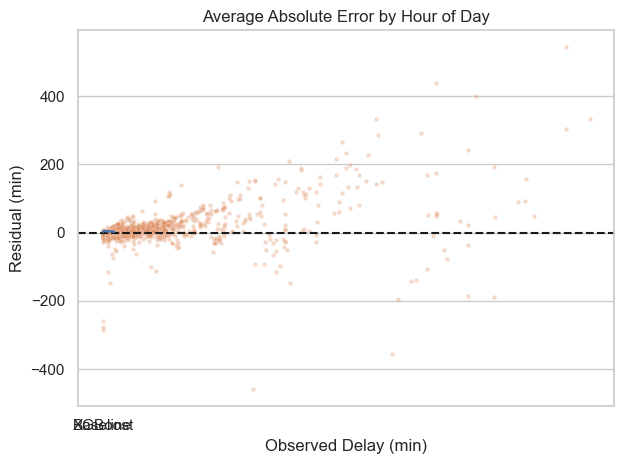

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")  # clean look

# 1. Bar chart: baseline vs. model MAE
mae_df = pd.DataFrame({"Model": ["Baseline", "XGBoost"], "MAE": [16.38, 2.58]})
sns.barplot(x="Model", y="MAE", data=mae_df, palette="viridis")
plt.title("Mean Absolute Error by Model")
plt.ylabel("Minutes"); plt.tight_layout(); plt.savefig("mae_compare.png")

# 2. Residual scatter
residuals_b = y_test_b - y_pred_b
sns.scatterplot(x=y_test_b, y=residuals_b, alpha=0.3, s=10)
plt.axhline(0, ls="--", c="k")
plt.xlabel("Observed Delay (min)"); plt.ylabel("Residual (min)")
plt.title("Residuals vs. Observed Delay"); plt.tight_layout()

# 3. Error by hour
err_by_hr_b = (abs(residuals_b).groupby(X_test_b['hour']).mean().reset_index())
sns.lineplot(x="hour", y="Min Delay", data=err_by_hr_b)
plt.title("Average Absolute Error by Hour of Day"); plt.tight_layout()


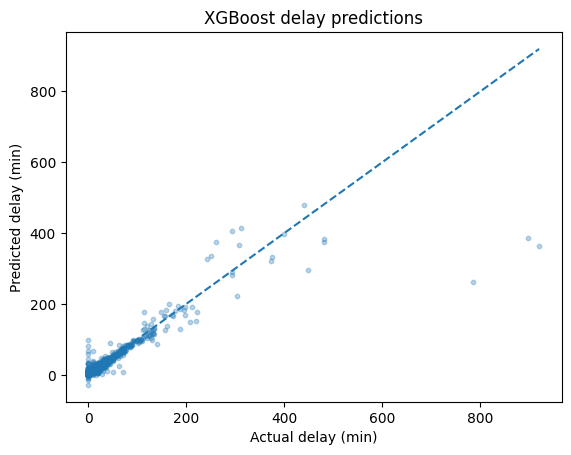

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], ls="--")
plt.xlabel("Actual delay (min)"); plt.ylabel("Predicted delay (min)")
plt.title("XGBoost delay predictions"); plt.show()


# --- Modeling: Bus Delay Prediction ---
All steps for bus delay prediction (variables with _b).

In [17]:
# 1) Convert wx_mod['Date'] (which was object/str) into a real datetime
wx_mod['Date'] = pd.to_datetime(wx_mod['Date'])

# 2) Make sure strcar_df['Date'] is also datetime64[ns]
strcar_df['Date'] = pd.to_datetime(strcar_df['Date'])
bus_df['Date'] = pd.to_datetime(bus_df['Date'])


In [23]:
w_bus_df.shape

(707397, 18)

In [31]:
ttc_b['delay_ma7'].isna().sum()  # should be 0, if no NaNs in Min Delay

np.int64(0)

In [32]:
ttc_b['delay_ma7'].isna().sum()  # should be 0, if no NaNs in Min Delay

np.int64(0)

<Axes: >

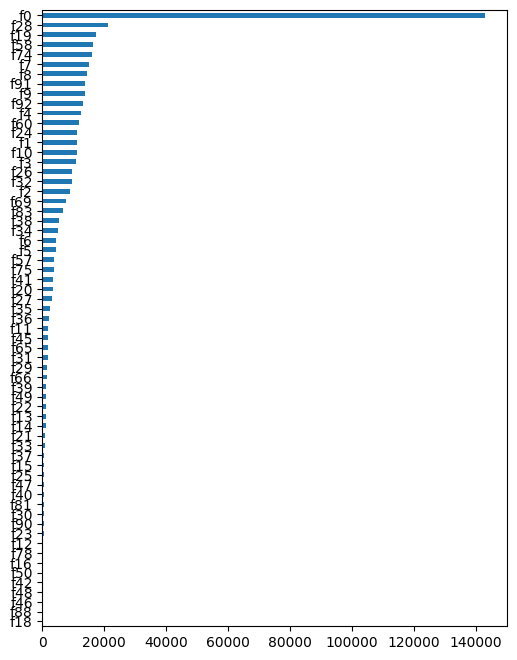

In [ ]:
booster = best_pipe.named_steps["xgb"].get_booster()
gain_imp = booster.get_score(importance_type="gain")
pd.Series(gain_imp).sort_values().plot.barh(figsize=(6,8))


# --- Results & Evaluation ---
Model evaluation metrics and analysis.

In [44]:
import pandas as pd

# 1-a. Best hyper-parameters and objective
print("Best MAE from CV:", study.best_value)
print("Best params:");  print(study.best_params)

# 1-b. Full trial table, ranked
trials_df = study.trials_dataframe(attrs=("number","value","params","state"))
display(trials_df.sort_values("value").head())


Best MAE from CV: 3.0256446221504465
Best params:
{'n_estimators': 447, 'lr': 0.010315037228659852, 'depth': 9, 'min_child': 4, 'subsample': 0.815096032607437, 'colsample': 0.9537776656354224, 'alpha': 1.1977097975786168e-05, 'lambda': 1.8741462444713093e-07, 'gamma': 3.6308443909416708}


,number,value,params_alpha,params_colsample,params_depth,params_gamma,params_lambda,params_lr,params_min_child,params_n_estimators,params_subsample,state
3,3,3.025645,0.000012,0.953778,9,3.630844,1.874146e-07,0.010315,4,447,0.815096,COMPLETE
19,19,3.040424,0.000023,0.858500,9,1.655739,1.225164e-08,0.015613,1,884,0.828914,COMPLETE
35,35,3.040424,0.001803,0.586496,7,2.781768,5.236941e-08,0.060868,15,1099,0.528729,COMPLETE
33,33,3.040424,0.015682,0.794817,11,2.771114,3.565017e-07,0.061957,5,566,0.921008,COMPLETE
31,31,3.040424,0.007735,0.951729,11,3.473494,3.007245e-07,0.002999,6,769,0.779772,COMPLETE


In [ ]:
mae_global = (y_test - y_train.mean()).abs().mean()


# --- Visualization ---
Visualization of results using matplotlib/seaborn.

In [3]:
file_path = "/Users/zmasarweh/Downloads/testest/events_data.json"
df = pd.read_json(file_path)

In [4]:
df.head()

,calEvent
0,"{'categoryString': 'Literary,Talks', 'accessib..."
1,"{'categoryString': 'Arts/Exhibits,Seminars/Wor..."
2,"{'categoryString': 'Arts/Exhibits', 'accessibi..."
3,"{'categoryString': 'Family/Children,Food/Culin..."
4,"{'categoryString': 'Arts/Exhibits,Seminars/Wor..."
